# MLflow — pipeline run history
Each pipeline run (every 5 minutes) creates an MLflow run.
Here we collect them all and plot the metrics.

In [1]:
from pathlib import Path
import mlflow

project_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
mlflow.set_tracking_uri(f"sqlite:///{project_dir / 'mlflow.db'}")
runs = mlflow.search_runs(experiment_names=["diabetes-prediction"])
print(f"Total pipeline runs logged: {len(runs)}")
cols = ["start_time", "metrics.accuracy", "metrics.recall", "metrics.f1", "metrics.roc_auc"]
runs[cols].tail(10)

Total pipeline runs logged: 5


,start_time,metrics.accuracy,metrics.recall,metrics.f1,metrics.roc_auc
0,2026-09-15 15:35:50.652000+00:00,0.7403,0.6429,0.6429,0.7996
1,2026-09-15 15:30:46.481000+00:00,0.7403,0.6429,0.6429,0.7996
2,2026-09-15 15:28:53.554000+00:00,0.7403,0.6429,0.6429,0.7996
3,2026-09-15 15:25:34.838000+00:00,0.7403,0.6429,0.6429,0.7996
4,2026-09-15 14:18:44.543000+00:00,0.7403,0.6429,0.6429,0.7996


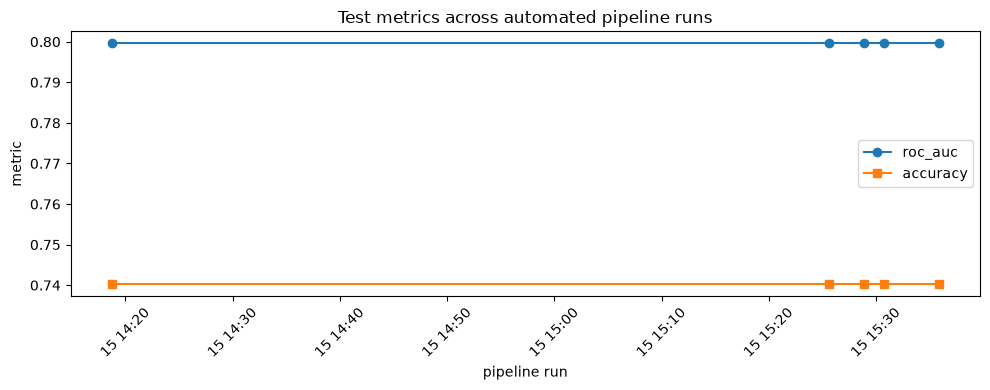

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(runs["start_time"], runs["metrics.roc_auc"], marker="o", label="roc_auc")
ax.plot(runs["start_time"], runs["metrics.accuracy"], marker="s", label="accuracy")
ax.set_xlabel("pipeline run")
ax.set_ylabel("metric")
ax.legend()
ax.set_title("Test metrics across automated pipeline runs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()